In [1]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

options = {"thermal": "lumped"}

## Model for NVPF/HC sodium ion battery only

In [2]:
model = pybamm.sodium_ion.BasicDFN()

In [3]:
parameter_values = pybamm.ParameterValues("Chayambuka2022")

In [4]:
# Cell design specific parameters to be updated using values from the cell design tool
# For sodium Std. 18650 from Mahesh's thesis
parameter_values.update({
                        "Negative electrode thickness [m]": 65e-6*1.135, # 1.135 for ratio of the areas of the negative electrode to the positive electrode from the cell design tool.
                        "Negative electrode porosity": 0.51,
                        "Negative electrode active material volume fraction": 0.489,
                        
                        
                        "Separator thickness [m]": 25e-6,
                        "Separator porosity": 0.54,
                        
                        "Positive electrode thickness [m]": 68e-6,
                        "Positive electrode porosity": 0.22,
                        "Positive electrode active material volume fraction": 0.56,
                        
                        #use the lesser values of (cathode, anode)
                        "Electrode height [m]": 200e-3, 
                        "Electrode width [m]": 167e-3*194*2, # 194 is the number of layers in parallel, 167 mm is the width of a single layer
                         
                        "Nominal cell capacity [A.h]": 158,
                        "Current function [A]": 158,
                        "Contact resistance [Ohm]": 0.001,
                        "Cell volume [m3]": 2580e-06,
                        
                        },check_already_exists=False)

parameter_values.update({
                        
                        "Maximum concentration in negative electrode [mol.m-3]": 14540, #to be calculated from mAh/g
                        "Maximum concentration in positive electrode [mol.m-3]": 15320, #to be calculated from mAh/g
                        # leave it to default values for now
                        })


In [5]:
C_rates_in = 1

In [6]:
sim = pybamm.Simulation(model=model, parameter_values=parameter_values, C_rate=C_rates_in)
sim.solve([0, 3600/C_rates_in])
sim.plot()

/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/src/pybamm/simulation.py:122: UserWarning: The default solver changed to IDAKLUSolver after the v25.4.0. release. You can swap back to the previous default by using `pybamm.CasadiSolver()` instead.
  self._solver = solver or self._model.default_solver


interactive(children=(FloatSlider(value=0.0, description='t', max=2904.2211154240617, step=29.04221115424062),…

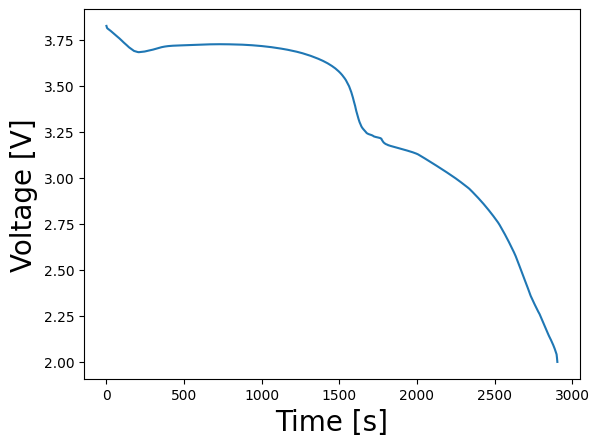

Text(0, 0.5, 'Voltage [V]')

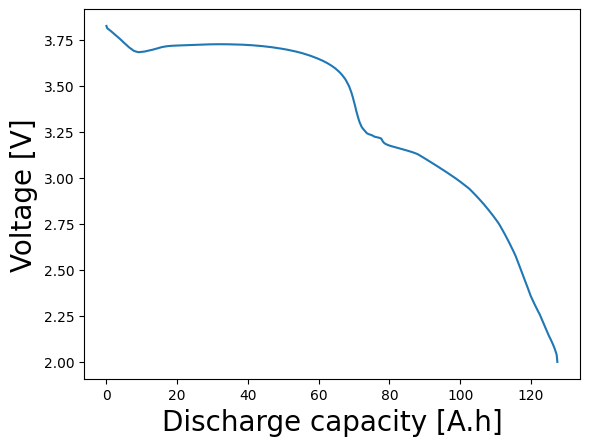

In [7]:
t1 = sim.solution["Time [s]"].entries
Vc1 = sim.solution["Battery voltage [V]"].entries
Qd1 = sim.solution["Discharge capacity [A.h]"].entries


plt.plot(t1, Vc1)
plt.xlabel("Time [s]",fontsize=20)
#plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)
plt.show()
plt.plot(Qd1,Vc1)
#plt.xlabel("Time [h]",fontsize=20)
plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)